# HW12:
# Закрепить:
# - отличие временных рядов от обычных табличных данных с точки зрения валидации;
# - практику корректного `temporal split` вместо случайного `random split`;
# - построение лаговых, rolling- и календарных признаков;
# - сравнение простых baseline-подходов с рекуррентной моделью;
# - аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.

# Импорты и настройка среды

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Seed для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Определение устройства (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создание папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

Используемое устройство: cpu


# Загрузка данных и первичный анализ

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Количество пропусков:
date      0
target    0
dtype: int64

Первые 5 строк:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


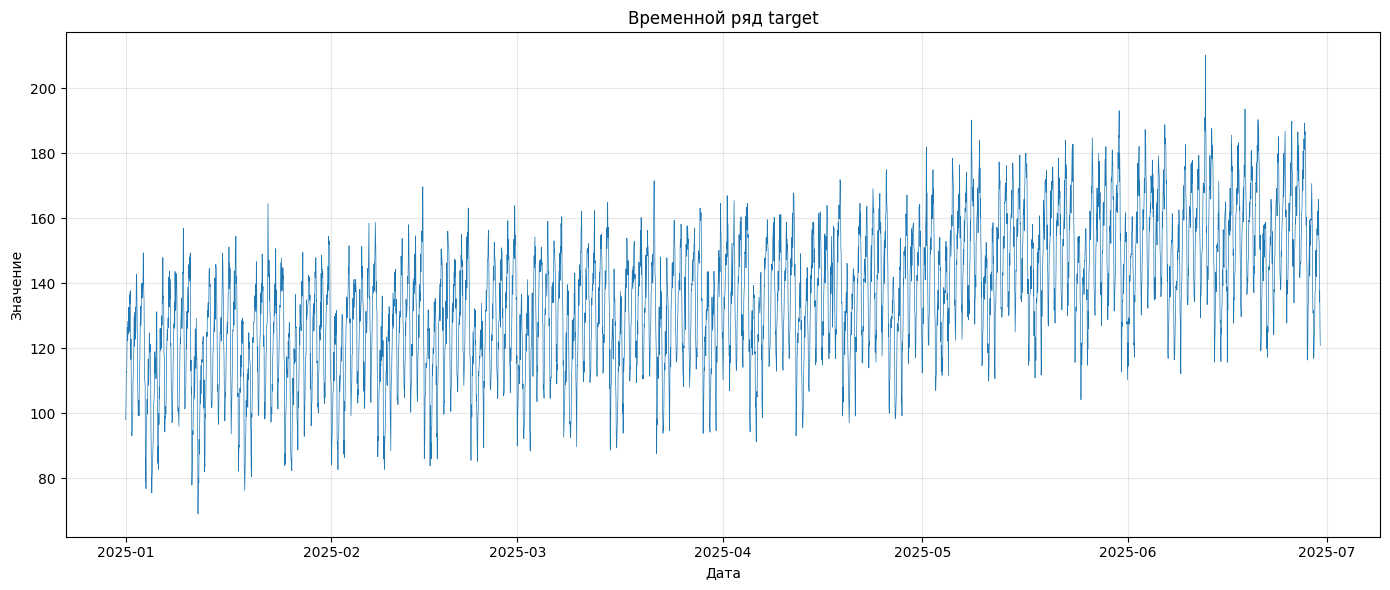


Комментарий к ряду:
- Тренд: присутствует
- Сезонность: требует дополнительного анализа
- Выбросы: требуют проверки


In [ ]:
# Загрузка датасета
df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование колонки date в datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка по времени
df = df.sort_values('date').reset_index(drop=True)

# Первичный осмотр данных
print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Количество пропусков:\n{df.isna().sum()}")
print(f"\nПервые 5 строк:\n{df.head()}")
print(f"\nСтатистика target:\n{df['target'].describe()}")

Базовый график временного ряда и проверка на стационарность (визуальная)

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_overview.png', dpi=150)
plt.show()

print("\nКомментарий к ряду:")
print("- Тренд: присутствует" if df['target'].diff().mean() != 0 else "- Тренд: отсутствует")
print("- Сезонность: требует дополнительного анализа")
print("- Выбросы: требуют проверки")

# Корректный Temporal Split

РАЗДЕЛЕНИЕ ДАННЫХ
Train: 3024 записей (2025-01-01 00:00:00 - 2025-05-06 23:00:00)
Val:   648 записей (2025-05-07 00:00:00 - 2025-06-02 23:00:00)
Test:  648 записей (2025-06-03 00:00:00 - 2025-06-29 23:00:00)


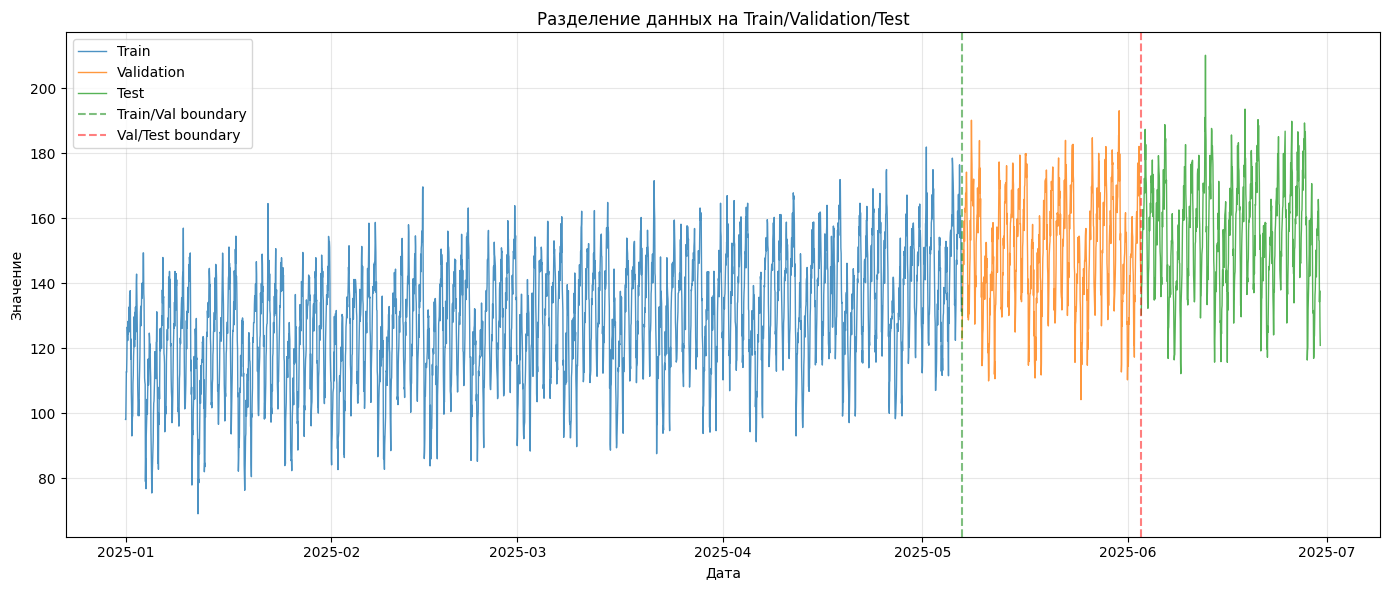


Почему random split некорректен для временных рядов:
1. Нарушается временная зависимость между наблюдениями
2. Модель может 'заглянуть в будущее' (data leakage)
3. Не оценивается способность модели прогнозировать будущие значения


In [ ]:
# Определение границ split
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

# Разделение данных по времени
train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print("=" * 50)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 50)
print(f"Train: {len(train_df)} записей ({train_df['date'].min()} - {train_df['date'].max()})")
print(f"Val:   {len(val_df)} записей ({val_df['date'].min()} - {val_df['date'].max()})")
print(f"Test:  {len(test_df)} записей ({test_df['date'].min()} - {test_df['date'].max()})")

Визуализация split и объяснение почему random split некорректен

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', linewidth=1, alpha=0.8)
plt.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1, alpha=0.8)
plt.plot(test_df['date'], test_df['target'], label='Test', linewidth=1, alpha=0.8)
plt.axvline(x=train_df['date'].max(), color='green', linestyle='--', alpha=0.5, label='Train/Val boundary')
plt.axvline(x=val_df['date'].max(), color='red', linestyle='--', alpha=0.5, label='Val/Test boundary')
plt.title('Разделение данных на Train/Validation/Test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

print("\nПочему random split некорректен для временных рядов:")
print("1. Нарушается временная зависимость между наблюдениями")
print("2. Модель может 'заглянуть в будущее' (data leakage)")
print("3. Не оценивается способность модели прогнозировать будущие значения")

# Построение признаков для baseline-моделей

In [ ]:
def create_features(df, target_col='target'):
    """
    Создание лаговых, rolling и календарных признаков.
    Важно: признаки строятся без утечки из будущего!
    """
    df = df.copy()
    
    # Лаговые признаки
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)
    
    # Rolling признаки
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    
    # Календарные признаки из даты
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

ПРИЗНАКИ ПОСЛЕ ОБРАБОТКИ
Train размер после удаления NaN: 3010
Val размер после удаления NaN: 634
Test размер после удаления NaN: 634

Колонки признаков:
['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']

Масштабирование выполнено (fit только на train)


Создание признаков для всех сплитов и удаление строк с NaN

In [ ]:
train_features = create_features(train_df)
val_features = create_features(val_df)
test_features = create_features(test_df)

train_features = train_features.dropna().reset_index(drop=True)
val_features = val_features.dropna().reset_index(drop=True)
test_features = test_features.dropna().reset_index(drop=True)

print("=" * 50)
print("ПРИЗНАКИ ПОСЛЕ ОБРАБОТКИ")
print("=" * 50)
print(f"Train размер после удаления NaN: {len(train_features)}")
print(f"Val размер после удаления NaN: {len(val_features)}")
print(f"Test размер после удаления NaN: {len(test_features)}")
print(f"\nКолонки признаков:\n{train_features.columns.tolist()}")

Определение признаков и таргета

In [ ]:
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']
target_col = 'target'

X_train = train_features[feature_cols].values
y_train = train_features[target_col].values
X_val = val_features[feature_cols].values
y_val = val_features[target_col].values
X_test = test_features[feature_cols].values
y_test = test_features[target_col].values

Масштабирование признаков и таргета

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(f"\nМасштабирование выполнено (fit только на train)")

# Dataset и DataLoader для GRU

In [ ]:
class TimeSeriesDataset(Dataset):
    """
    Dataset для временных рядов с оконным представлением.
    """
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x = self.X[idx:idx + self.window_size]
        y = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Параметры окна для GRU
WINDOW_SIZE = 24
BATCH_SIZE = 32

# Создание датасетов
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=" * 50)
print("GRU DATASET И DATALOADER")
print("=" * 50)
print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Проверка формы данных
for x_batch, y_batch in train_loader:
    print(f"\nФорма batch X: {x_batch.shape}")
    print(f"Форма batch y: {y_batch.shape}")
    break

GRU DATASET И DATALOADER
Window size: 24
Batch size: 32
Train batches: 94
Val batches: 20
Test batches: 20

Форма batch X: torch.Size([32, 24, 10])
Форма batch y: torch.Size([32, 1])


# Модель GRU

In [ ]:
class GRUModel(nn.Module):
    """
    GRU модель для прогнозирования временных рядов.
    """
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = gru_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Параметры модели
INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

# Инициализация модели
model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print("=" * 50)
print("ПАРАМЕТРЫ МОДЕЛИ GRU")
print("=" * 50)
print(f"Input size: {INPUT_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Num layers: {NUM_LAYERS}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Device: {device}")

ПАРАМЕТРЫ МОДЕЛИ GRU
Input size: 10
Hidden size: 64
Num layers: 2
Dropout: 0.2
Learning rate: 0.001
Num epochs: 50
Device: cpu


# Функции обучения и оценки

In [ ]:
def calculate_metrics(y_true, y_pred):
    """
    Расчет метрик MAE, RMSE, MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Один эпоб обучения.
    """
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device, scaler=None):
    """
    Оценка модели на валидации/тесте.
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            
            all_preds.append(output.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    
    # Обратное масштабирование если передан scaler
    if scaler is not None:
        all_preds = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
        all_targets = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()
    
    return total_loss / len(loader), all_preds, all_targets

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, target_scaler, patience=10):
    """
    Полный цикл обучения с early stopping и сохранением лучшей модели.
    """
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        val_loss, val_preds, val_targets = evaluate(
            model, val_loader, criterion, device, scaler=target_scaler
        )
        val_mae, _, _ = calculate_metrics(val_targets, val_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val MAE: {val_mae:.4f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

# Инициализация
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("=" * 50)
print("ФУНКЦИИ ОБУЧЕНИЯ ГОТОВЫ")
print("=" * 50)

ФУНКЦИИ ОБУЧЕНИЯ ГОТОВЫ


# Эксперимент B1 - Naive Last

In [ ]:
def naive_last_forecast(train_features, val_features, test_features, target_col='target'):
    """
    Baseline B1: Прогноз = последнее известное значение из train.
    Важно: используем train_features после dropna, чтобы длины совпадали
    """
    # Для валидации: последнее значение из train_features
    last_train_value = train_features[target_col].iloc[-1]
    val_preds = np.full(len(val_features), last_train_value)
    
    # Для теста: последнее значение из train_features + val_features
    last_val_value = pd.concat([train_features, val_features])[target_col].iloc[-1]
    test_preds = np.full(len(test_features), last_val_value)
    
    return val_preds, test_preds

# Запуск B1
val_preds_b1, test_preds_b1 = naive_last_forecast(train_features, val_features, test_features)

# Метрики
val_mae_b1, val_rmse_b1, val_mape_b1 = calculate_metrics(
    val_features[target_col].values, val_preds_b1
)
test_mae_b1, test_rmse_b1, test_mape_b1 = calculate_metrics(
    test_features[target_col].values, test_preds_b1
)

print("=" * 50)
print("ЭКСПЕРИМЕНТ B1: Naive Last")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b1:.4f}, RMSE: {val_rmse_b1:.4f}, MAPE: {val_mape_b1:.2f}%")
print(f"Test - MAE: {test_mae_b1:.4f}, RMSE: {test_rmse_b1:.4f}, MAPE: {test_mape_b1:.2f}%")

# Сохранение результатов B1
results_b1 = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last - прогноз равен последнему известному значению',
    'features_summary': 'None',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b1,
    'best_val_rmse': val_rmse_b1,
    'best_val_mape': val_mape_b1,
    'test_mae': test_mae_b1,
    'test_rmse': test_rmse_b1,
    'test_mape': test_mape_b1,
    'notes': 'Baseline без обучения'
}

ЭКСПЕРИМЕНТ B1: Naive Last
Validation - MAE: 20.3959, RMSE: 24.4460, MAPE: 12.89%
Test - MAE: 20.5253, RMSE: 24.6704, MAPE: 12.56%


# Эксперимент B2 - Moving Average

In [31]:
def moving_average_forecast(train_features, val_features, test_features, window=7, target_col='target'):
    """
    Baseline B2: Прогноз = скользящее среднее по окну.
    Важно: используем train_features после dropna
    """
    # Для валидации: среднее по последним window значениям train_features
    train_window = train_features[target_col].iloc[-window:].mean()
    val_preds = np.full(len(val_features), train_window)
    
    # Для теста: среднее по последним window значениям train_features + val_features
    combined = pd.concat([train_features, val_features])
    combined_window = combined[target_col].iloc[-window:].mean()
    test_preds = np.full(len(test_features), combined_window)
    
    return val_preds, test_preds

# Запуск B2
WINDOW_MA = 7
val_preds_b2, test_preds_b2 = moving_average_forecast(
    train_features, val_features, test_features, window=WINDOW_MA
)

# Метрики
val_mae_b2, val_rmse_b2, val_mape_b2 = calculate_metrics(
    val_features[target_col].values, val_preds_b2
)
test_mae_b2, test_rmse_b2, test_mape_b2 = calculate_metrics(
    test_features[target_col].values, test_preds_b2
)

print("=" * 50)
print(f"ЭКСПЕРИМЕНТ B2: Moving Average (window={WINDOW_MA})")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b2:.4f}, RMSE: {val_rmse_b2:.4f}, MAPE: {val_mape_b2:.2f}%")
print(f"Test - MAE: {test_mae_b2:.4f}, RMSE: {test_rmse_b2:.4f}, MAPE: {test_mape_b2:.2f}%")

# Сохранение результатов B2
results_b2 = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': WINDOW_MA,
    'horizon': 1,
    'model_summary': f'Moving Average с окном {WINDOW_MA}',
    'features_summary': 'None',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b2,
    'best_val_rmse': val_rmse_b2,
    'best_val_mape': val_mape_b2,
    'test_mae': test_mae_b2,
    'test_rmse': test_rmse_b2,
    'test_mape': test_mape_b2,
    'notes': 'Baseline без обучения'
}

ЭКСПЕРИМЕНТ B2: Moving Average (window=7)
Validation - MAE: 14.7664, RMSE: 17.7061, MAPE: 9.90%
Test - MAE: 14.2211, RMSE: 17.2223, MAPE: 9.40%


# Эксперимент B3 - Ridge Lag Features

In [ ]:
# Обучение Ridge на лаговых и rolling признаках
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Предсказания
val_preds_b3 = ridge_model.predict(X_val_scaled)
test_preds_b3 = ridge_model.predict(X_test_scaled)

# Метрики
val_mae_b3, val_rmse_b3, val_mape_b3 = calculate_metrics(y_val, val_preds_b3)
test_mae_b3, test_rmse_b3, test_mape_b3 = calculate_metrics(y_test, test_preds_b3)

print("=" * 50)
print("ЭКСПЕРИМЕНТ B3: Ridge на лаговых признаках")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b3:.4f}, RMSE: {val_rmse_b3:.4f}, MAPE: {val_mape_b3:.2f}%")
print(f"Test - MAE: {test_mae_b3:.4f}, RMSE: {test_rmse_b3:.4f}, MAPE: {test_mape_b3:.2f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nТоп-5 признаков по важности:\n{feature_importance.head()}")

# Сохранение результатов B3
results_b3 = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge Regression на лаговых и rolling признаках',
    'features_summary': str(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'Closed-form solution',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b3,
    'best_val_rmse': val_rmse_b3,
    'best_val_mape': val_mape_b3,
    'test_mae': test_mae_b3,
    'test_rmse': test_rmse_b3,
    'test_mape': test_mape_b3,
    'notes': f'Alpha={ridge_model.alpha}'
}

ЭКСПЕРИМЕНТ B3: Ridge на лаговых признаках
Validation - MAE: 6.3563, RMSE: 7.8471, MAPE: 4.25%
Test - MAE: 5.9853, RMSE: 7.5943, MAPE: 3.85%

Топ-5 признаков по важности:
      feature  coefficient
0       lag_1    12.594375
9  is_weekend    -4.623721
8       month     3.805567
1       lag_7    -3.350542
2      lag_14    -2.445495


# Эксперимент R1 - GRU Forecast

In [33]:
print("=" * 50)
print("ЭКСПЕРИМЕНТ R1: GRU Forecast")
print("=" * 50)
print("Начало обучения модели...")

# Обучение модели
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    target_scaler=target_scaler,
    patience=10
)

# Оценка на валидации
val_loss, val_preds_r1, val_targets_r1 = evaluate(
    model, val_loader, criterion, device, scaler=target_scaler
)
val_mae_r1, val_rmse_r1, val_mape_r1 = calculate_metrics(val_targets_r1, val_preds_r1)

# Оценка на тесте
test_loss, test_preds_r1, test_targets_r1 = evaluate(
    model, test_loader, criterion, device, scaler=target_scaler
)
test_mae_r1, test_rmse_r1, test_mape_r1 = calculate_metrics(test_targets_r1, test_preds_r1)

print(f"\nValidation - MAE: {val_mae_r1:.4f}, RMSE: {val_rmse_r1:.4f}, MAPE: {val_mape_r1:.2f}%")
print(f"Test - MAE: {test_mae_r1:.4f}, RMSE: {test_rmse_r1:.4f}, MAPE: {test_mape_r1:.2f}%")

# Сохранение результатов R1
results_r1 = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
    'features_summary': str(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'best_val_mae': val_mae_r1,
    'best_val_rmse': val_rmse_r1,
    'best_val_mape': val_mape_r1,
    'test_mae': test_mae_r1,
    'test_rmse': test_rmse_r1,
    'test_mape': test_mape_r1,
    'notes': f'Early stopping patience=10'
}

# Сохранение лучшей модели GRU
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("\nМодель GRU сохранена в artifacts/best_gru.pt")

# Сохранение конфига модели
gru_config = {
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_epochs': NUM_EPOCHS,
    'seed': SEED,
    'feature_cols': feature_cols,
    'scaler_type': 'StandardScaler'
}
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=4, ensure_ascii=False)
print("Конфиг GRU сохранен в artifacts/best_gru_config.json")

ЭКСПЕРИМЕНТ R1: GRU Forecast
Начало обучения модели...
Epoch 10/50 - Train Loss: 0.0977, Val Loss: 0.1546, Val MAE: 5.8972
Epoch 20/50 - Train Loss: 0.0893, Val Loss: 0.1306, Val MAE: 5.3831
Epoch 30/50 - Train Loss: 0.0862, Val Loss: 0.1632, Val MAE: 6.1288
Early stopping at epoch 32

Validation - MAE: 5.8775, RMSE: 7.3708, MAPE: 3.86%
Test - MAE: 5.9715, RMSE: 7.6214, MAPE: 3.77%

Модель GRU сохранена в artifacts/best_gru.pt
Конфиг GRU сохранен в artifacts/best_gru_config.json


# Визуализация кривых обучения GRU

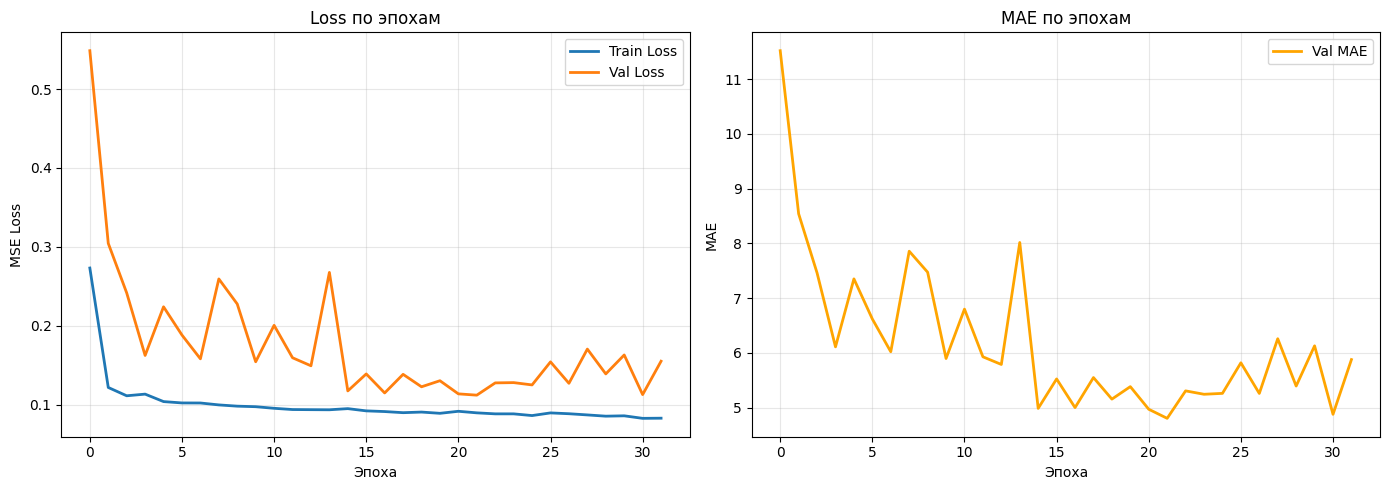

In [34]:
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# MAE
plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', linewidth=2, color='orange')
plt.title('MAE по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Сравнение всех подходов

Результаты сохранены в artifacts/runs.csv


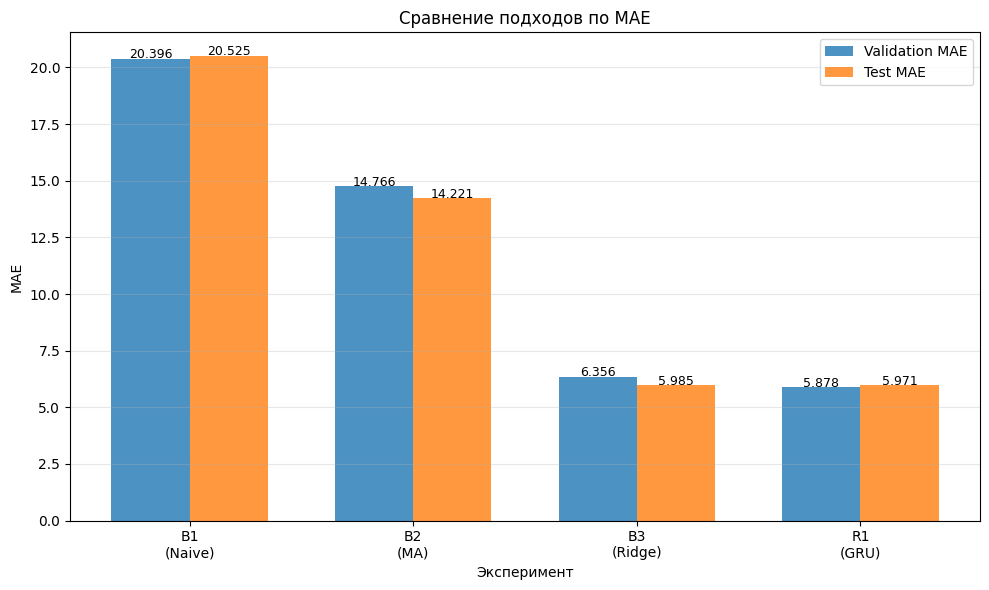


Лучший подход по Validation MAE: R1


In [35]:
# Сбор всех результатов
all_results = [results_b1, results_b2, results_b3, results_r1]
results_df = pd.DataFrame(all_results)

# Сохранение runs.csv
results_df.to_csv('artifacts/runs.csv', index=False, encoding='utf-8')
print("Результаты сохранены в artifacts/runs.csv")

# Визуализация сравнения по MAE
plt.figure(figsize=(10, 6))
experiments = ['B1\n(Naive)', 'B2\n(MA)', 'B3\n(Ridge)', 'R1\n(GRU)']
val_maes = [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1]
test_maes = [test_mae_b1, test_mae_b2, test_mae_b3, test_mae_r1]

x = np.arange(len(experiments))
width = 0.35

plt.bar(x - width/2, val_maes, width, label='Validation MAE', alpha=0.8)
plt.bar(x + width/2, test_maes, width, label='Test MAE', alpha=0.8)

plt.xlabel('Эксперимент')
plt.ylabel('MAE')
plt.title('Сравнение подходов по MAE')
plt.xticks(x, experiments)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for i, (v, t) in enumerate(zip(val_maes, test_maes)):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# Определение лучшего подхода по validation MAE
best_idx = np.argmin(val_maes)
best_experiment = ['B1', 'B2', 'B3', 'R1'][best_idx]
print(f"\nЛучший подход по Validation MAE: {best_experiment}")

# Финальный прогноз лучшей модели на Test

Длина дат: 634
Длина прогноза: 610
Длина фактических значений: 634


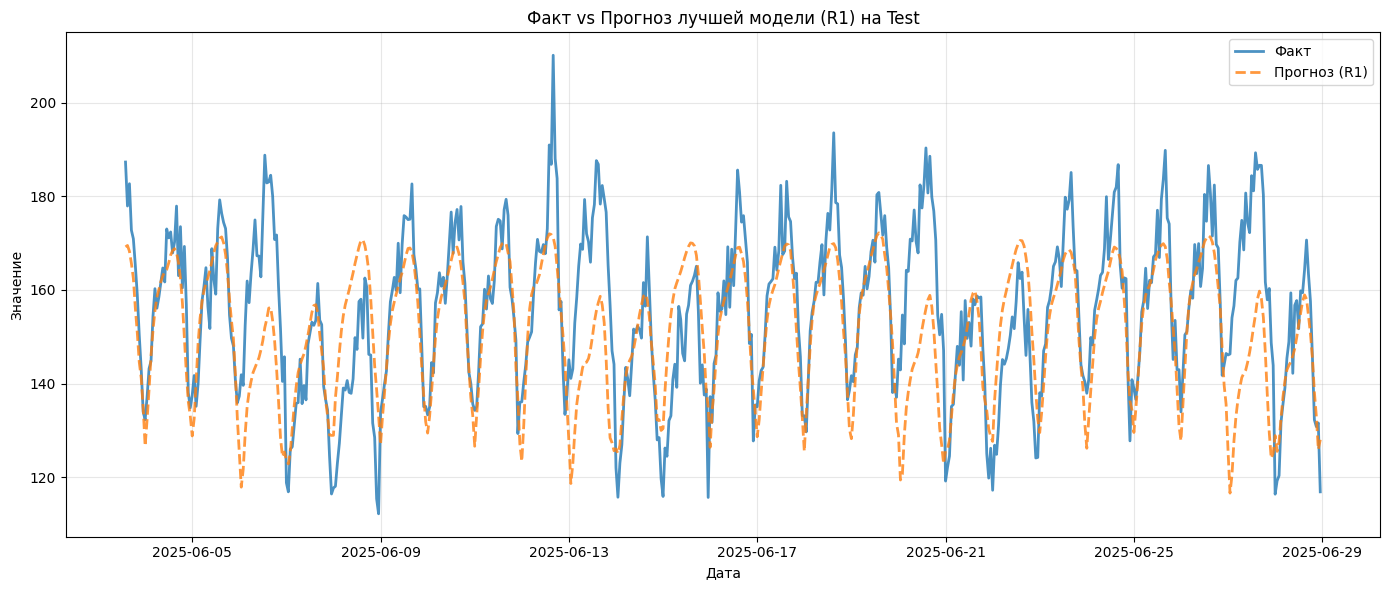

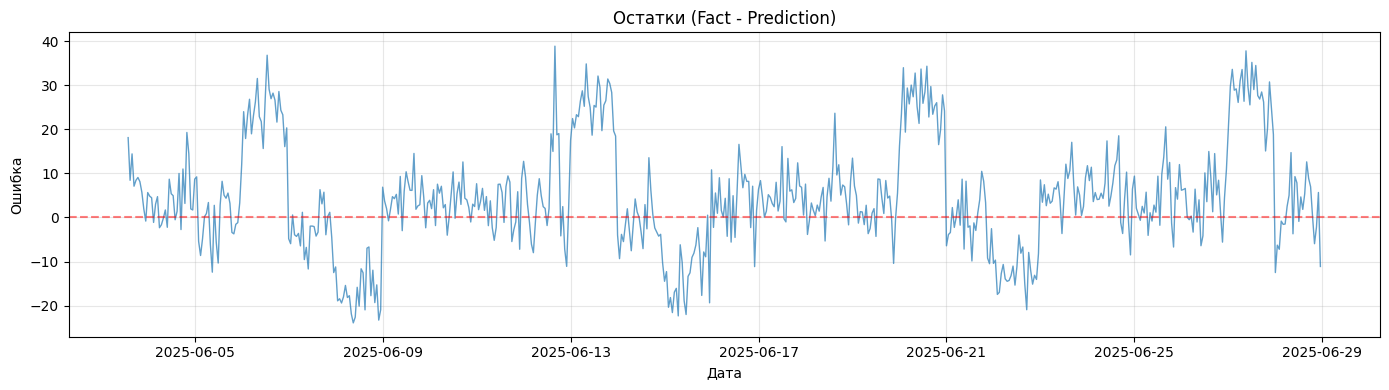


Метрики лучшей модели (R1) на Test:
MAE: 9.7659
RMSE: 13.1264
MAPE: 6.20%


In [ ]:
# Выбор лучшей модели и её прогноза
if best_experiment == 'B1':
    best_test_preds = test_preds_b1
elif best_experiment == 'B2':
    best_test_preds = test_preds_b2
elif best_experiment == 'B3':
    best_test_preds = test_preds_b3
else:  # R1
    best_test_preds = test_preds_r1

# Целевые значения из test_features
best_test_targets = test_features[target_col].values

test_dates = test_features['date'].values

# Проверка длин
print(f"Длина дат: {len(test_dates)}")
print(f"Длина прогноза: {len(best_test_preds)}")
print(f"Длина фактических значений: {len(best_test_targets)}")

# Обрезаем до минимальной длины если есть несоответствие
min_len = min(len(test_dates), len(best_test_preds), len(best_test_targets))
test_dates = test_dates[:min_len]
best_test_preds = best_test_preds[:min_len]
best_test_targets = best_test_targets[:min_len]

Визуализация факта и прогноза

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, best_test_targets, label='Факт', linewidth=2, alpha=0.8)
plt.plot(test_dates, best_test_preds, label=f'Прогноз ({best_experiment})', 
         linewidth=2, alpha=0.8, linestyle='--')
plt.title(f'Факт vs Прогноз лучшей модели ({best_experiment}) на Test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

# Остатки
residuals = best_test_targets - best_test_preds
plt.figure(figsize=(14, 4))
plt.plot(test_dates, residuals, linewidth=1, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Остатки (Fact - Prediction)')
plt.xlabel('Дата')
plt.ylabel('Ошибка')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=150)
plt.show()

print(f"\nМетрики лучшей модели ({best_experiment}) на Test:")
best_mae, best_rmse, best_mape = calculate_metrics(best_test_targets, best_test_preds)
print(f"MAE: {best_mae:.4f}")
print(f"RMSE: {best_rmse:.4f}")
print(f"MAPE: {best_mape:.2f}%")

# Сводная таблица результатов

In [37]:
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)

summary_df = results_df[['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape',
                          'test_mae', 'test_rmse', 'test_mape']].copy()
summary_df.columns = ['Эксперимент', 'Val MAE', 'Val RMSE', 'Val MAPE (%)', 
                       'Test MAE', 'Test RMSE', 'Test MAPE (%)']

# Форматирование
for col in summary_df.columns[1:]:
    if 'MAPE' in col:
        summary_df[col] = summary_df[col].apply(lambda x: f'{x:.2f}')
    else:
        summary_df[col] = summary_df[col].apply(lambda x: f'{x:.4f}')

print(summary_df.to_string(index=False))

# Выбор лучшей модели
best_val_mae_idx = results_df['best_val_mae'].idxmin()
best_model = results_df.loc[best_val_mae_idx]
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model['experiment_id']}")
print(f"Validation MAE: {best_model['best_val_mae']:.4f}")
print(f"Test MAE: {best_model['test_mae']:.4f}")

print("\n" + "=" * 80)
print("АРТЕФАКТЫ СОХРАНЕНЫ В ПАПКУ artifacts/")
print("=" * 80)
print("- runs.csv - таблица результатов")
print("- best_gru.pt - веса лучшей GRU модели")
print("- best_gru_config.json - конфиг GRU модели")
print("- figures/series_split.png - визуализация split")
print("- figures/baselines_compare.png - сравнение подходов")
print("- figures/gru_learning_curves.png - кривые обучения GRU")
print("- figures/best_forecast_test.png - факт vs прогноз")
print("- figures/residuals_best.png - остатки лучшей модели")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Эксперимент Val MAE Val RMSE Val MAPE (%) Test MAE Test RMSE Test MAPE (%)
         B1 20.3959  24.4460        12.89  20.5253   24.6704         12.56
         B2 14.7664  17.7061         9.90  14.2211   17.2223          9.40
         B3  6.3563   7.8471         4.25   5.9853    7.5943          3.85
         R1  5.8775   7.3708         3.86   5.9715    7.6214          3.77

ЛУЧШАЯ МОДЕЛЬ: R1
Validation MAE: 5.8775
Test MAE: 5.9715

АРТЕФАКТЫ СОХРАНЕНЫ В ПАПКУ artifacts/
- runs.csv - таблица результатов
- best_gru.pt - веса лучшей GRU модели
- best_gru_config.json - конфиг GRU модели
- figures/series_split.png - визуализация split
- figures/baselines_compare.png - сравнение подходов
- figures/gru_learning_curves.png - кривые обучения GRU
- figures/best_forecast_test.png - факт vs прогноз
- figures/residuals_best.png - остатки лучшей модели
